In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
import warnings

warnings.filterwarnings("ignore")

# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv")
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


In [3]:

print(f"Our total rows are {df.shape[0]} and columns are {df.shape[1]}")
df.info()
print("-"*100)
df.isnull().sum()

Our total rows are 200000 and columns are 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB
----------------------------------------------------------------------------------------------------


Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64

In [4]:
df.duplicated().sum()
df.columns
# I was working with pipeline then i git an error and i then realized that wasn't done before so i done it nwo
df["Amount"]=df['Amount'].str.replace("$","")
df["Amount"].value_counts()
df["Amonut"]=df["Amount"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
 11  Amonut           200000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 18.3+ MB


In [5]:
#First import important libraries

from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# ***Demand Forecasting***
***is a type of data science in which we predict the demand as in this dataset we will make the model which oredicts the demand of chocolate boxes which needed to ship in specific countries and how much boxes will countries will order***

In [6]:
# Drop rows where the target 'Boxes_Shipped' is missing
df_clean = df.dropna(subset=["Boxes_Shipped"])

# Separate features (X) and target (y)
X = df_clean.drop(columns=["Boxes_Shipped", "Order_ID"])  # Also dropping Order_ID as it's useless for ML
y = df_clean["Boxes_Shipped"]


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#To define our Column Transformer first we will just separate our numerical and categorical columns
num_cols=["Discount_Pct","Price_per_Box","Marketing_Spend","Amount"]
cat_cols=["Product","Country","Channel", "Salesperson"]

#First we will create mini pipeline to encode and imoute categorical column
cat_transformer=Pipeline(steps=[("impute",SimpleImputer(strategy="most_frequent"))
                                ,("encode",OneHotEncoder(handle_unknown="ignore",sparse_output=False)),
                               ])
#Then our Final Pipeline will become
preprocessor=ColumnTransformer(transformers=[
    ("cat_cols",cat_transformer,cat_cols),
    ("num_cols",KNNImputer(n_neighbors=5),num_cols),
])

#Now implement it on X 
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

# ***Model selection and Tuning***
***in this step we will choose the model and tune them according to the dataset and then made them passthrough for loop one by one and determine the winner on basis of MAE and R²***

In [8]:
#First we will select our all models
# Highly optimized "Smart Defaults" for mobile training
models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42),
    
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_split=5, n_jobs=-1, random_state=42),
    
    "XGBoost": XGBRegressor(n_estimators=500, max_depth=3,min_child_weight=5, learning_rate=0.01, subsample=0.8, colsample_bytree=0.6,reg_lambda=7,reg_alpha=2.5,n_jobs=-1, random_state=42),
    
    "LightGBM": LGBMRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, num_leaves=31, n_jobs=-1, verbose=-1, random_state=42),
    
    "CatBoost": CatBoostRegressor(iterations=500, depth=6, learning_rate=0.01, verbose=0, random_state=42)
}


In [9]:

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_processed, y_train)
    # Predict
    preds = model.predict(X_test_processed)
    # Evaluate
    results[name] = {
        "MAE": round(mean_absolute_error(y_test, preds), 2),
        "R2": round(r2_score(y_test, preds), 4)
    }

# Convert to DataFrame and print
df_results = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)
print(df_results)


                 MAE      R2
Random Forest  12.36  0.8538
CatBoost       12.52  0.8371
LightGBM       12.14  0.8366
Decision Tree  14.79  0.8298
XGBoost        18.23  0.8132


# ***Q.Which Country Shipped the Most Chocolate boxes?***

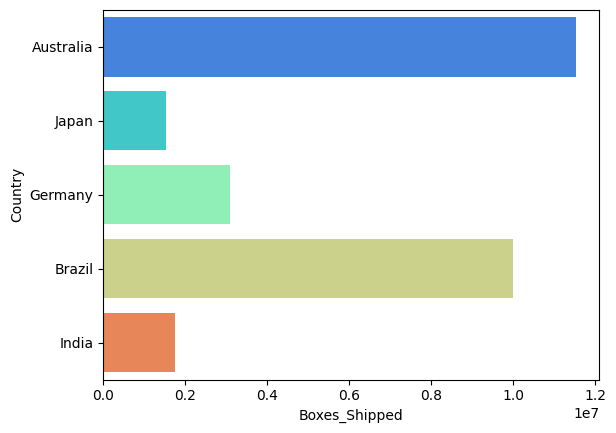

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
# Just a simple bar plot
sns.barplot(data=df, y="Country", x="Boxes_Shipped", estimator="sum", ci=None, palette="rainbow")
plt.show()


***I guess now we have our answer***

# ***Channel Vs Boxshipped As this graph shows a direct comparison of how many total chocolate boxes were sold through each sales method***


***•The X-axis (Bottom):-*** Lists your sales channels (e.g., Retail, Online, Wholesale).
***•The Y-axis (Left Side):*** Shows the total number of physical boxes shipped.
***•The Height of the Bars:*** The taller the bar, the more boxes were sold through that specific channel.

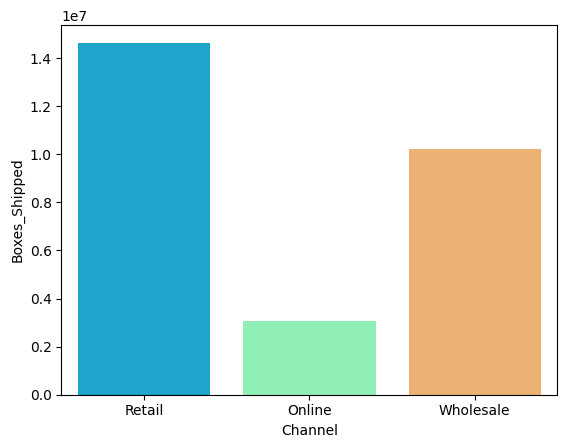

In [11]:
# Just a simple bar plot for channels
sns.barplot(data=df, x="Channel", y="Boxes_Shipped", estimator="sum", ci=None, palette="rainbow")
plt.show()


The retail method sales the most chocolate according to our analysis 

In [12]:
with open("requirements.txt", "w") as f:
    f.write(
        "streamlit\npandas\nseaborn\nmatplotlib\nscikit-learn==1.6.1\n"
    )
    from IPython.display import FileLink

FileLink("requirements.txt")


/kaggle/working/requirements.txt

In [13]:
import os

os.makedirs(".streamlit", exist_ok=True)
with open(".streamlit/config.toml", "w") as f:
    f.write(
        "[theme]\nprimaryColor='#C68B59'\nbackgroundColor='#2B1B17'\nsecondaryBackgroundColor='#3D2B1F'\ntextColor='#FFFFFF'\n"
    )
    FileLink(".streamlit/config.toml")
    